**Generate Dataset**

In [13]:
import pandas as pd
import numpy as np

np.random.seed(100)
n = 5000  # 5000 pelanggan

# Generate Fitur Dasar
customer_id = [f'CUST-{i:04d}' for i in range(1, n+1)]
tenure = np.random.randint(1, 73, n)  # 1 - 72 bulan
monthly_charges = np.round(np.random.uniform(20, 120, n), 2)
contract = np.random.choice(['Month-to-month', 'One Year', 'Two Year'], n, p=[0.55, 0.25, 0.20])
payment = np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n, p=[0.4, 0.2, 0.2, 0.2])
has_tech_support = np.random.binomial(1, 0.45, n)
has_online_security = np.random.binomial(1, 0.50, n)
support_tickets = np.random.poisson(lam=1.5, size=n) # rata-rata 1.5 tiket
usage = np.random.normal(100, 25, n).astype(int)
usage = np.maximum(usage, 10) # minimal 10 jam

# Generate Target (Churn) dengan LOGIKA BISNIS
churn_prob = np.zeros(n)

for i in range(n):
    prob = 0.05  # baseline churn 5%

    # Aturan 1: Contract month-to-month meningkatkan risiko 3x lipat
    if contract[i] == 'Month-to-month':
        prob += 0.25
    elif contract[i] == 'One Year':
        prob += 0.05
    else: # Two Year
        prob -= 0.05

    # Aturan 2: Electronic check (cenderung tidak otomatis) riskan
    if payment[i] == 'Electronic check':
        prob += 0.15

    # Aturan 3: Tidak ada tech support + security
    if has_tech_support[i] == 0 and has_online_security[i] == 0:
        prob += 0.20

    # Aturan 4: Banyak tiket keluhan
    if support_tickets[i] >= 5:
        prob += 0.30
    elif support_tickets[i] >= 3:
        prob += 0.20

    # Aturan 5: Tenure muda (kurang dari 6 bulan) sangat riskan
    if tenure[i] < 6:
        prob += 0.20
    elif tenure[i] > 36:
        prob -= 0.10

    # Aturan 6: Harga tinggi tapi pemakaian rendah -> tidak puas
    if monthly_charges[i] > 80 and usage[i] < 50:
        prob += 0.15

    # Clip probabilitas antara 0 dan 1
    churn_prob[i] = np.clip(prob, 0.01, 0.98)

# Sample berdasarkan probabilitas yang telah dihitung
churn = np.random.binomial(1, churn_prob)

# Buat DataFrame
df = pd.DataFrame({
    'customer_id': customer_id,
    'tenure_months': tenure,
    'monthly_charges': monthly_charges,
    'total_charges': monthly_charges * tenure, # perkiraan total
    'contract_type': contract,
    'payment_method': payment,
    'has_tech_support': has_tech_support,
    'has_online_security': has_online_security,
    'num_support_tickets': support_tickets,
    'avg_monthly_usage': usage,
    'churn': churn
})

# Cek hasil (rata-rata churn sekitar 25-30% agar realistis)
print(df.head())
print(f"\nOverall Churn Rate: {df['churn'].mean():.2%}")
df.to_csv('saas_churn_data.csv', index=False)

  customer_id  tenure_months  monthly_charges  total_charges   contract_type  \
0   CUST-0001              9            76.46         688.14  Month-to-month   
1   CUST-0002             25            88.75        2218.75        Two Year   
2   CUST-0003             68            81.44        5537.92        One Year   
3   CUST-0004             49           109.22        5351.78  Month-to-month   
4   CUST-0005             11            77.99         857.89  Month-to-month   

     payment_method  has_tech_support  has_online_security  \
0  Electronic check                 1                    1   
1       Credit card                 0                    1   
2      Mailed check                 0                    0   
3  Electronic check                 0                    0   
4  Electronic check                 0                    1   

   num_support_tickets  avg_monthly_usage  churn  
0                    2                 92      0  
1                    2                111   

**Library and Environment**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Interpretasi (Opsional)
import shap

In [15]:
#DATA Cleaning

print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          5000 non-null   object 
 1   tenure_months        5000 non-null   int64  
 2   monthly_charges      5000 non-null   float64
 3   total_charges        5000 non-null   float64
 4   contract_type        5000 non-null   object 
 5   payment_method       5000 non-null   object 
 6   has_tech_support     5000 non-null   int64  
 7   has_online_security  5000 non-null   int64  
 8   num_support_tickets  5000 non-null   int64  
 9   avg_monthly_usage    5000 non-null   int64  
 10  churn                5000 non-null   int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 429.8+ KB
None
customer_id            0
tenure_months          0
monthly_charges        0
total_charges          0
contract_type          0
payment_method         0
has_tech_support       0

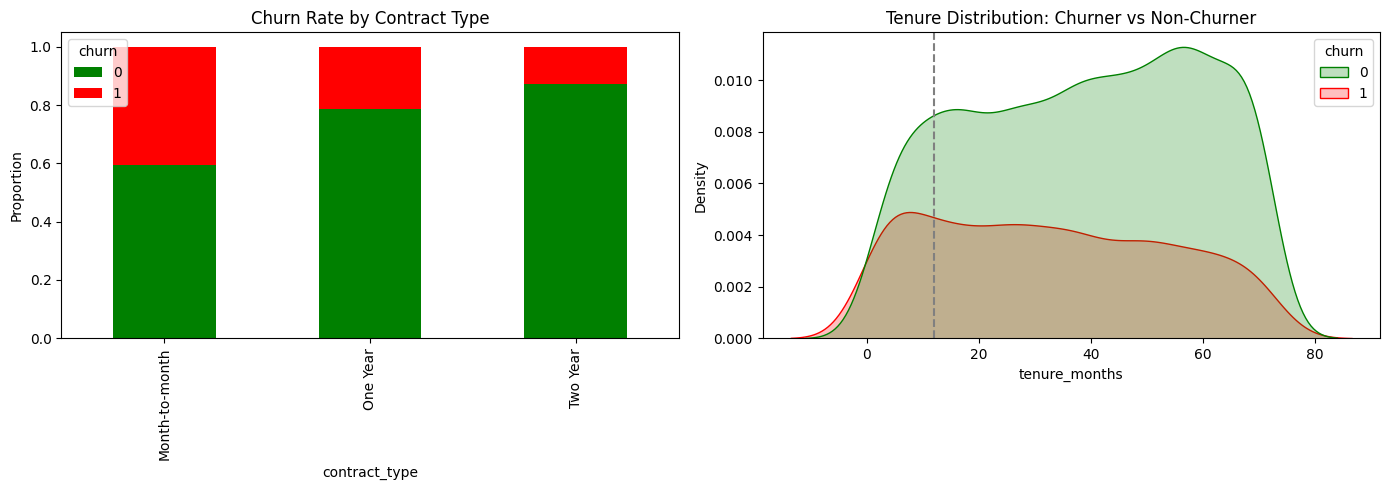

In [16]:
#EDA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract vs Churn
pd.crosstab(df['contract_type'], df['churn'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0], color=['green', 'red']
)
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Proportion')

# Tenure vs Churn
sns.kdeplot(data=df, x='tenure_months', hue='churn', fill=True, ax=axes[1], palette=['green', 'red'])
axes[1].set_title('Tenure Distribution: Churner vs Non-Churner')
axes[1].axvline(x=12, linestyle='--', color='gray')

plt.tight_layout()
plt.show()

In [17]:
#Feature engineering

df['tenure_group'] = pd.cut(df['tenure_months'],
                             bins=[0, 6, 18, 100],
                             labels=['New', 'Medium', 'Long'])

In [18]:
#Preprocessing for modeling

# Pisahkan fitur dan target
X = df.drop(['customer_id', 'churn', 'tenure_group'], axis=1)
# tenure_group kita drop agar tidak duplikasi dengan tenure_months
y = df['churn']

# Split data (70% train, 30% test) dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Definisikan kolom numerik dan kategorikal
numeric_features = ['tenure_months', 'monthly_charges', 'total_charges', 'num_support_tickets', 'avg_monthly_usage', 'has_tech_support', 'has_online_security']
categorical_features = ['contract_type', 'payment_method']

# Buat Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

In [19]:
#Modeling (Logistic regresion & Random Forest)

# Model 1: Logistic Regression (dengan class_weight untuk mengatasi imbalance)
lr = LogisticRegression(class_weight='balanced', random_state=42)
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', lr)])

# Model 2: Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', rf)])

# Train kedua model
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure_months',
                                                   'monthly_charges',
                                                   'total_charges',
                                                   'num_support_tickets',
                                                   'avg_monthly_usage',
                                                   'has_tech_support',
                                                   'has_online_security']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['contract_type',
                                                   'payment_method'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [20]:
#Evaluation

# Prediksi
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluasi
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Churn', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, pipeline_lr.predict_proba(X_test)[:,1]):.3f}")

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Churn', 'Churn']))
print(f"AUC-ROC: {roc_auc_score(y_test, pipeline_rf.predict_proba(X_test)[:,1]):.3f}")

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

   Non-Churn       0.82      0.66      0.73      1044
       Churn       0.46      0.66      0.54       456

    accuracy                           0.66      1500
   macro avg       0.64      0.66      0.64      1500
weighted avg       0.71      0.66      0.67      1500

AUC-ROC: 0.726

=== RANDOM FOREST ===
              precision    recall  f1-score   support

   Non-Churn       0.74      0.89      0.81      1044
       Churn       0.53      0.29      0.37       456

    accuracy                           0.71      1500
   macro avg       0.63      0.59      0.59      1500
weighted avg       0.68      0.71      0.68      1500

AUC-ROC: 0.696


In [21]:
#Interpretation and insight

# Ekstrak koefisien
lr_model = pipeline_lr.named_steps['classifier']
feature_names = (numeric_features +
                 list(pipeline_lr.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coef': lr_model.coef_[0]
})
coef_df['Odds_Ratio'] = np.exp(coef_df['Coef'])
coef_df = coef_df.sort_values('Odds_Ratio', ascending=False)

print(coef_df[['Feature', 'Odds_Ratio']].head(10))
# Insight: Jika odds ratio > 1, maka kenaikan 1 unit variabel itu meningkatkan risiko churn.

                            Feature  Odds_Ratio
10  payment_method_Electronic check    1.915255
3               num_support_tickets    1.456503
4                 avg_monthly_usage    1.052116
2                     total_charges    1.016618
1                   monthly_charges    0.965204
11      payment_method_Mailed check    0.869734
9        payment_method_Credit card    0.822980
5                  has_tech_support    0.752156
6               has_online_security    0.742524
0                     tenure_months    0.673912
